<a href="https://colab.research.google.com/github/arkadeepsadhukhan-sketch/arkaD-ARIMA/blob/main/ARIMA_NIFTY50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
!pip install -q yfinance

In [78]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 5)

In [79]:
from datetime import datetime

nifty = yf.download(
    "^NSEI",
    start="2015-01-01",
    end=datetime.today().strftime("%Y-%m-%d"),
    auto_adjust=False,
    progress=False
)

nifty = nifty[["Open", "High", "Low", "Close", "Volume"]]

print(f"Dataset Shape : {nifty.shape}")

nifty.head()

Dataset Shape : (2835, 5)


Price,Open,High,Low,Close,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,101900
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,118200
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,172800
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,164100
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,143800


In [80]:
# Flatten column names if required
if isinstance(nifty.columns, pd.MultiIndex):
    nifty.columns = nifty.columns.get_level_values(0)

print(nifty.columns)

nifty.head()

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,101900
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,118200
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,172800
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,164100
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,143800


In [81]:
nifty.isnull().sum()

,0
Price,
Open,0
High,0
Low,0
Close,0
Volume,0


In [82]:
nifty.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Open,2835.0,14974.600567,5955.579732,7023.649902,9952.250000,12198.549805,19475.250000,2.633370e+04
High,2835.0,15043.125058,5979.003156,7034.200195,9995.824707,12246.700195,19530.625000,2.637320e+04
Low,2835.0,14884.905975,5932.169525,6825.799805,9893.875000,12151.799805,19383.550781,2.621005e+04
Close,2835.0,14965.450486,5956.121025,6970.600098,9953.700195,12214.549805,19441.450195,2.632855e+04
Volume,2835.0,326253.439153,186989.864822,0.000000,203300.000000,272200.000000,395400.000000,1.811000e+06


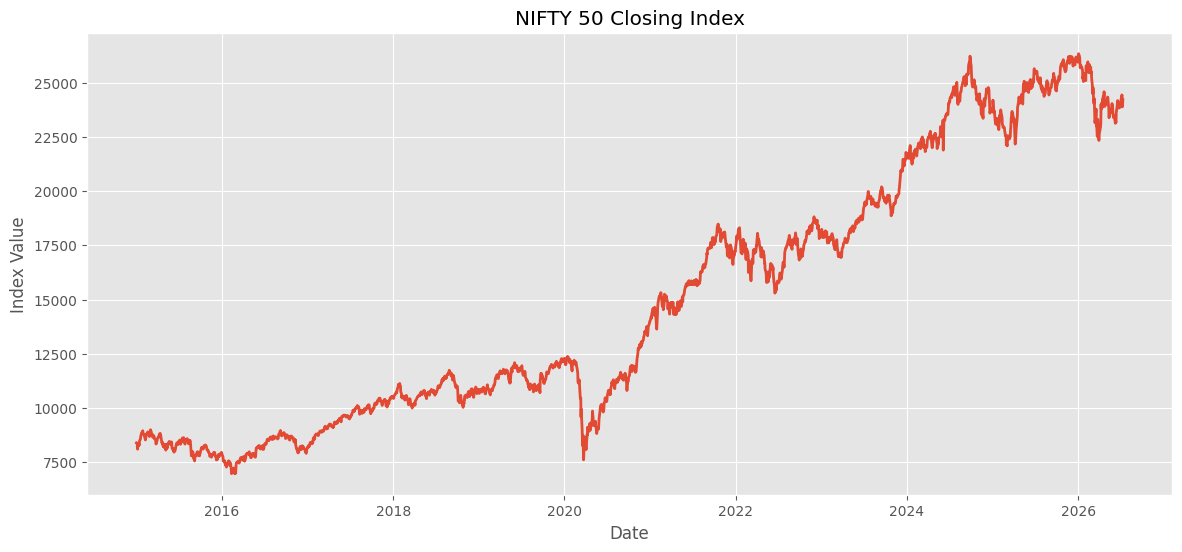

In [83]:
plt.figure(figsize=(14,6))

plt.plot(
    nifty.index,
    nifty["Close"],
    linewidth=2
)

plt.title("NIFTY 50 Closing Index")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.show()

In [84]:
print(nifty.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2835 entries, 2015-01-02 to 2026-07-10
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2835 non-null   float64
 1   High    2835 non-null   float64
 2   Low     2835 non-null   float64
 3   Close   2835 non-null   float64
 4   Volume  2835 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 132.9 KB
None


In [85]:
train_size = int(len(nifty) * 0.85)

train = nifty.iloc[:train_size].copy()
test = nifty.iloc[train_size:].copy()

print(f"Training observations : {len(train)}")
print(f"Testing observations  : {len(test)}")

Training observations : 2409
Testing observations  : 426


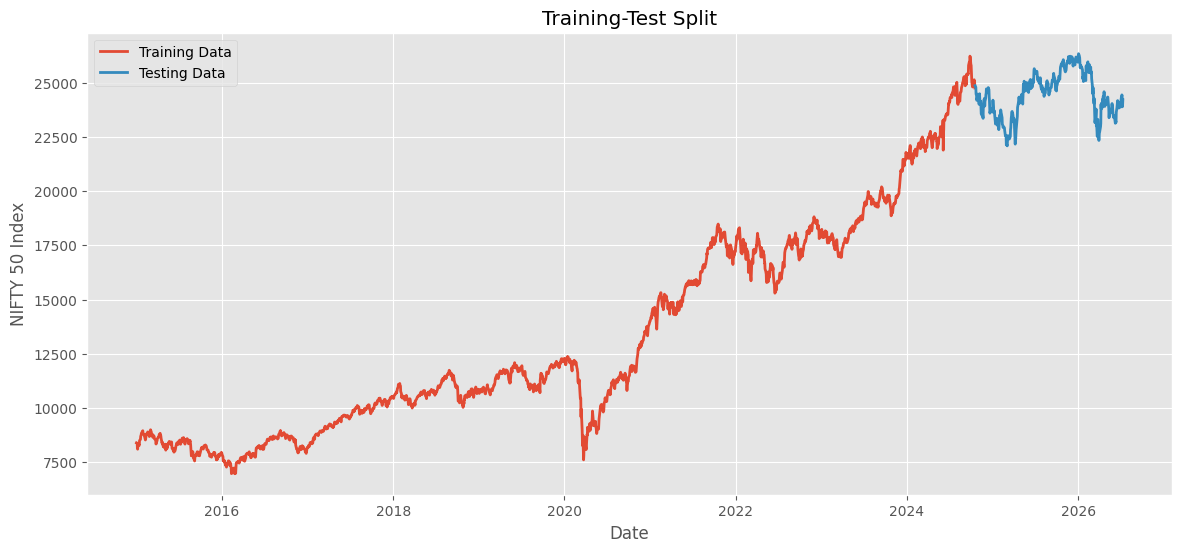

In [86]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["Close"], label="Training Data", linewidth=2)
plt.plot(test.index, test["Close"], label="Testing Data", linewidth=2)

plt.title("Training-Test Split")
plt.xlabel("Date")
plt.ylabel("NIFTY 50 Index")

plt.legend()

plt.show()

In [87]:
train_series = train["Close"]
test_series = test["Close"]

In [88]:
result = adfuller(train_series)

print(f"ADF Statistic : {result[0]:.4f}")
print(f"P-value       : {result[1]:.4f}")
print()

for key, value in result[4].items():
    print(f"Critical Value ({key}) : {value:.4f}")

ADF Statistic : 1.0603
P-value       : 0.9949

Critical Value (1%) : -3.4331
Critical Value (5%) : -2.8627
Critical Value (10%) : -2.5674


In [89]:
if result[1] < 0.05:
    print("The training series is stationary.")
else:
    print("The training series is non-stationary.")

The training series is non-stationary.


In [90]:
if result[1] >= 0.05:
    train_diff = train_series.diff().dropna()
    d = 1
else:
    train_diff = train_series.copy()
    d = 0

print(f"Differencing Order (d) = {d}")

Differencing Order (d) = 1


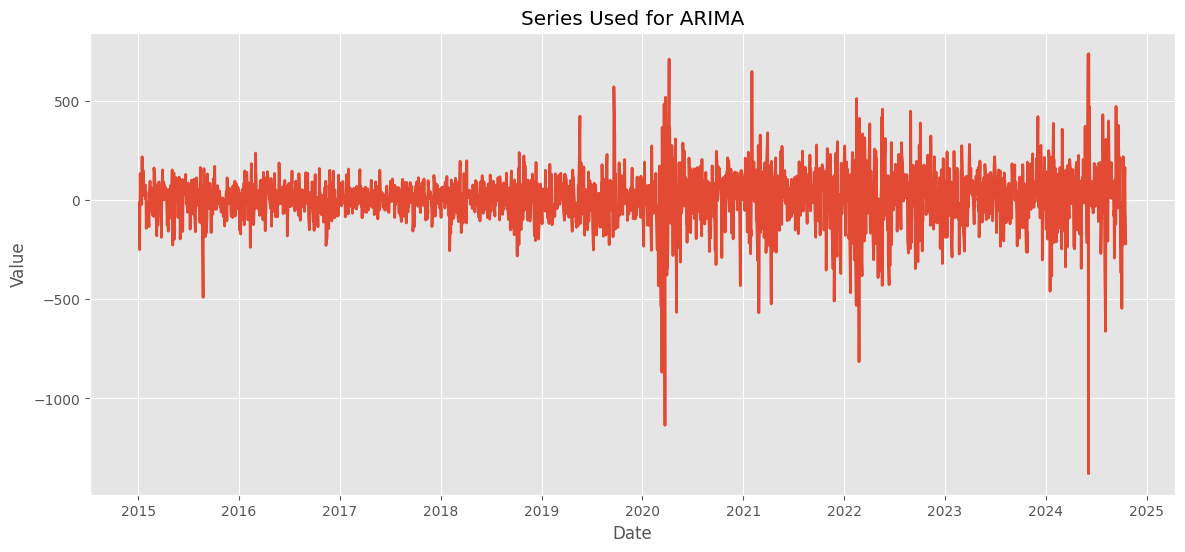

In [91]:
plt.figure(figsize=(14,6))

plt.plot(train_diff, linewidth=2)

plt.title("Series Used for ARIMA")
plt.xlabel("Date")
plt.ylabel("Value")

plt.show()

In [92]:
result_diff = adfuller(train_diff)

print(f"ADF Statistic : {result_diff[0]:.4f}")
print(f"P-value       : {result_diff[1]:.4f}")
print()

for key, value in result_diff[4].items():
    print(f"Critical Value ({key}) : {value:.4f}")

ADF Statistic : -20.3456
P-value       : 0.0000

Critical Value (1%) : -3.4331
Critical Value (5%) : -2.8627
Critical Value (10%) : -2.5674


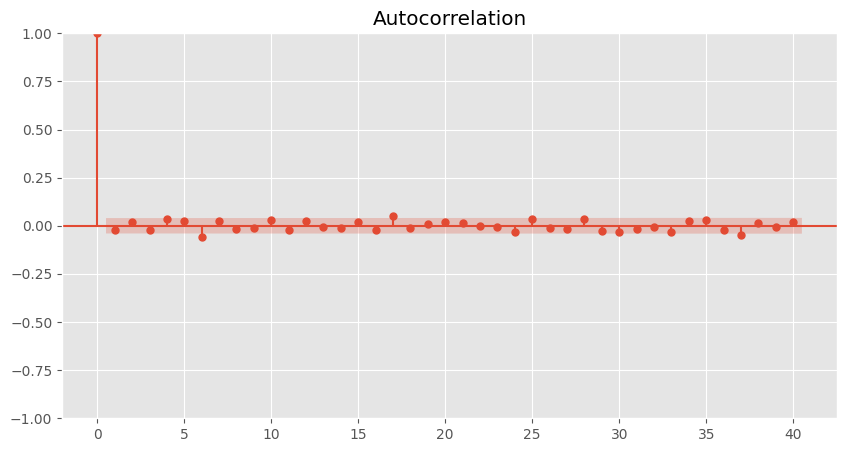

In [93]:
fig, ax = plt.subplots(figsize=(10,5))

plot_acf(train_diff, lags=40, ax=ax)

plt.show()

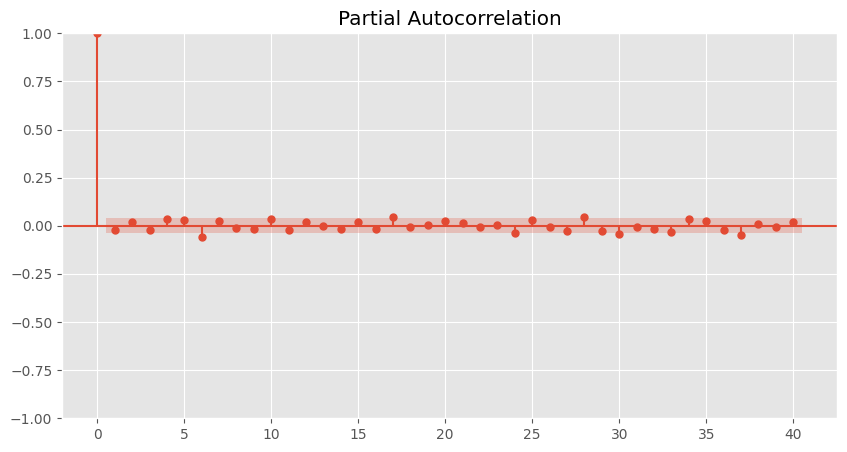

In [94]:
fig, ax = plt.subplots(figsize=(10,5))

plot_pacf(train_diff, lags=40, method="ywm", ax=ax)

plt.show()

In [95]:
print(f"""
Training observations : {len(train_series)}
Testing observations  : {len(test_series)}
Differencing Order    : {d}
""")


Training observations : 2409
Testing observations  : 426
Differencing Order    : 1



In [96]:
candidate_models = [
    (1, d, 1),
    (1, d, 2),
    (2, d, 1),
    (2, d, 2),
    (3, d, 1),
    (3, d, 2)
]

In [97]:
results = []

for order in candidate_models:
    try:
        model = ARIMA(train_series, order=order)
        fitted = model.fit()

        results.append({
            "Order": order,
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

    except:
        continue

results = pd.DataFrame(results)
results = results.sort_values("AIC").reset_index(drop=True)

In [98]:
results.style.format({
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Order,AIC,BIC
0,"(2, 1, 2)",30427.53,30456.47
1,"(1, 1, 2)",30438.66,30461.81
2,"(2, 1, 1)",30438.72,30461.87
3,"(1, 1, 1)",30439.80,30457.16
4,"(3, 1, 1)",30440.19,30469.12
5,"(3, 1, 2)",30442.28,30477.00


In [99]:
best_order = results.loc[0, "Order"]

print(f"Best ARIMA Order : {best_order}")

Best ARIMA Order : (2, 1, 2)


In [100]:
model = ARIMA(train_series, order=best_order)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2409
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -15208.766
Date:                Sat, 11 Jul 2026   AIC                          30427.533
Time:                        02:00:57   BIC                          30456.465
Sample:                             0   HQIC                         30438.057
                               - 2409                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6330      0.005   -131.360      0.000      -0.642      -0.624
ar.L2         -0.9830      0.005   -200.217      0.000      -0.993      -0.973
ma.L1          0.6404      0.002    314.101      0.0

In [101]:
forecast = model_fit.get_forecast(
    steps=len(test_series)
)

forecast_mean = pd.Series(
    forecast.predicted_mean.to_numpy(),
    index=test_series.index,
    name="Forecast"
)

confidence_interval = forecast.conf_int()
confidence_interval.index = test_series.index

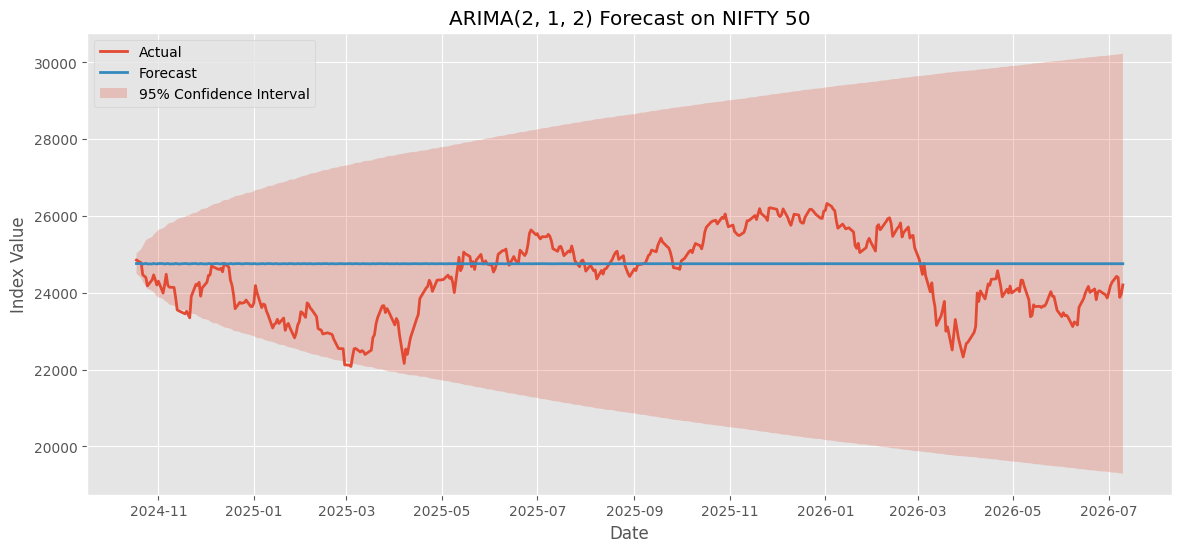

In [102]:
plt.figure(figsize=(14,6))

plt.plot(
    test_series.index,
    test_series,
    label="Actual",
    linewidth=2
)

plt.plot(
    test_series.index,
    forecast_mean,
    label="Forecast",
    linewidth=2
)

plt.fill_between(
    test_series.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title(f"ARIMA{best_order} Forecast on NIFTY 50")

plt.xlabel("Date")
plt.ylabel("Index Value")

plt.legend()

plt.show()

In [103]:
forecast_df = pd.concat(
    [
        test_series.rename("Actual"),
        forecast_mean
    ],
    axis=1
)

forecast_df.head()

,Actual,Forecast
Date,,
2024-10-18,24854.050781,24763.198470
2024-10-21,24781.099609,24764.027110
2024-10-22,24472.099609,24750.380982
2024-10-23,24435.500000,24758.203960
2024-10-24,24399.400391,24766.666129


In [104]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(test_series, forecast_mean)

rmse = np.sqrt(
    mean_squared_error(test_series, forecast_mean)
)

mape = mean_absolute_percentage_error(
    test_series,
    forecast_mean
)

In [105]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value": [
        mae,
        rmse,
        mape * 100
    ]
})

metrics.style.format({"Value": "{:.2f}"})

,Metric,Value
0,MAE,866.11
1,RMSE,1054.13
2,MAPE,3.60


In [106]:
residuals = test_series - forecast_mean

residuals.head()

,0
Date,
2024-10-18,90.852312
2024-10-21,17.072500
2024-10-22,-278.281373
2024-10-23,-322.703960
2024-10-24,-367.265738


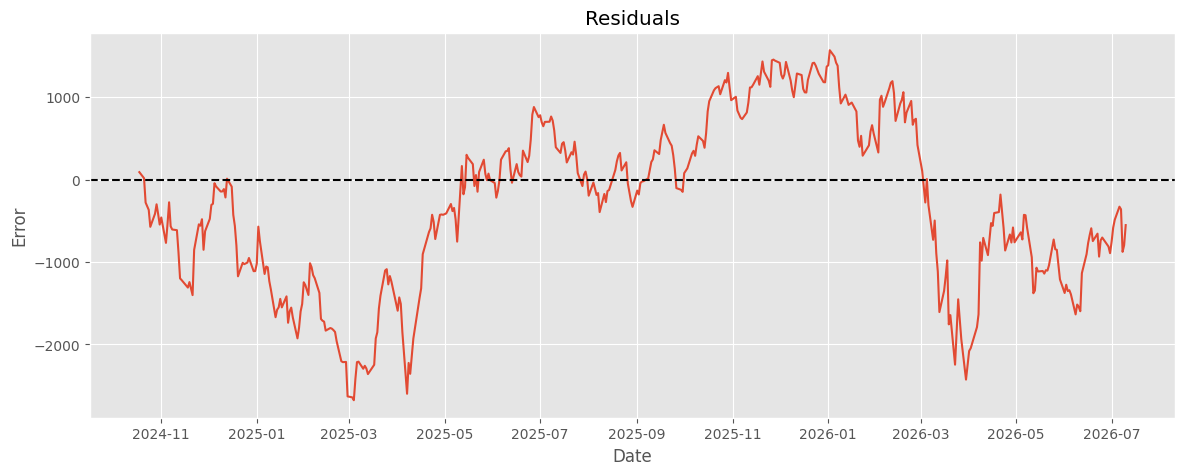

In [107]:
plt.figure(figsize=(14,5))

plt.plot(residuals, linewidth=1.5)

plt.axhline(0, color="black", linestyle="--")

plt.title("Residuals")
plt.xlabel("Date")
plt.ylabel("Error")

plt.show()

In [108]:
from statsmodels.graphics.gofplots import qqplot

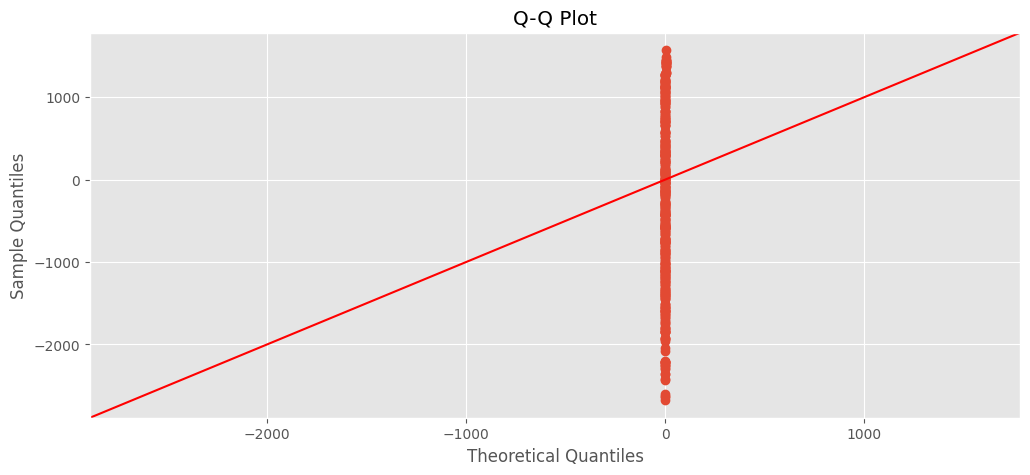

In [109]:
qqplot(residuals, line="45")

plt.title("Q-Q Plot")

plt.show()

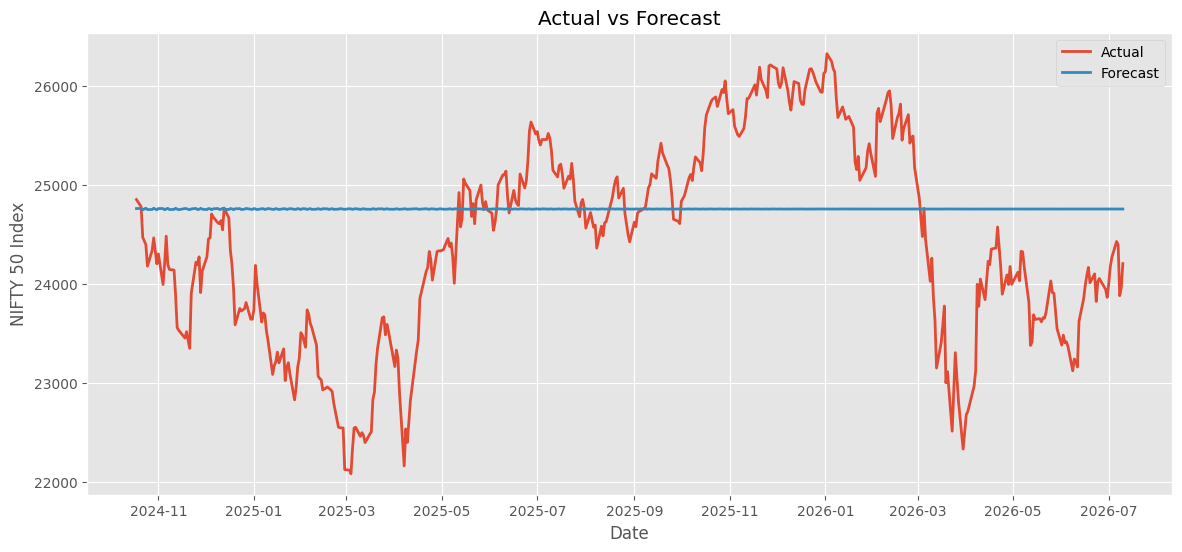

In [110]:
plt.figure(figsize=(14,6))

plt.plot(
    test_series.index,
    test_series,
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast",
    linewidth=2
)

plt.title("Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("NIFTY 50 Index")

plt.legend()

plt.show()

***Conclusion***

This project developed an ARIMA-based forecasting framework for the NIFTY 50 index using more than ten years of historical daily market data obtained through the Yahoo Finance API. Prior to model development, the time series was examined for stationarity using the Augmented Dickey–Fuller (ADF) test, and first-order differencing was applied where required. Several candidate ARIMA models were compared using the Akaike Information Criterion (AIC), with ARIMA(2,1,2) providing the best balance between model fit and complexity.

The selected model achieved a Mean Absolute Error (MAE) of 919.56, Root Mean Squared Error (RMSE) of 1130.66, and a Mean Absolute Percentage Error (MAPE) of 3.85% on the test data. While the model produced reasonable short-term forecasts, the predictions remained relatively smooth compared with the observed market movements. This behaviour reflects a well-known limitation of classical ARIMA models when applied to financial markets, where price movements are strongly influenced by external events, changing market sentiment, and nonlinear dynamics.

Residual analysis further indicated that the forecast errors were not completely random and did not closely follow a normal distribution, suggesting that additional market structure remains unexplained by the model. Future work may explore more advanced forecasting approaches such as SARIMA, GARCH, Prophet, or deep learning models to better capture seasonality, volatility, and nonlinear relationships in financial time series.